# 🧠 Handwritten Digit Classification — Multilayer Perceptron (MLP)
### End-to-End Deep Learning Pipeline on MNIST

---

**Author:** *(Your Name)*  
**Dataset:** MNIST — 70,000 grayscale images of handwritten digits (0–9)  
**Framework:** TensorFlow / Keras  
**Goal:** Design, train, evaluate and export a production-ready MLP classifier  

---

### 📋 Notebook Structure
| # | Section | Description |
|---|---------|-------------|
| 1 | Environment Setup | Imports, seeds, GPU check |
| 2 | Dataset Loading | MNIST via Keras |
| 3 | Exploratory Data Analysis | Visualizations, class balance |
| 4 | Preprocessing | Normalization, reshape, one-hot encoding |
| 5 | Model Architecture | MLP with BatchNorm + Dropout |
| 6 | Model Visualization | Architecture diagram |
| 7 | Training | Callbacks: EarlyStopping, LR decay, Checkpoint |
| 8 | Gradient Flow Analysis | Verify no vanishing/exploding gradients |
| 9 | Evaluation & Metrics | Accuracy, Precision, Recall, F1, ROC-AUC |
| 10 | Confusion Matrix | Counts + normalized heatmaps |
| 11 | Misclassification Analysis | Visual inspection of errors |
| 12 | Prediction Confidence | Calibration + per-class confidence |
| 13 | Model Robustness | Noise & blur stress tests |
| 14 | Parameter Summary | Layer-wise weight breakdown |
| 15 | Export | Save model for production/frontend |

---
## 1. 🔧 Environment Setup & Reproducibility

We fix all random seeds to ensure **fully reproducible results** across runs.  
We also verify GPU availability and library versions — essential for academic reproducibility.

In [1]:
# ── Dependency Installation ────────────────────────────────────────────
# Run this cell once if packages are missing
import subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'seaborn', 'scikit-learn', 'tensorflow']
for pkg in required:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('✅ All dependencies verified.')

✅ All dependencies verified.


In [2]:
# ── Core Imports ────────────────────────────────────────────────────────
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score,
    recall_score, f1_score, confusion_matrix, roc_auc_score,
    roc_curve
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# ── Reproducibility Seeds ────────────────────────────────────────────────
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Plot Style ───────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print(f'NumPy     : {np.__version__}')
print(f'TensorFlow: {tf.__version__}')
print(f'Keras     : {keras.__version__}')

NumPy     : 2.4.4
TensorFlow: 2.21.0
Keras     : 3.14.0


In [3]:
# ── Hardware Check ──────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'✅ GPU detected: {[g.name for g in gpus]}')
else:
    print('⚠️  No GPU detected — running on CPU (training will be slower)')

print(f'\n🔒 Random seed locked to: {SEED}')
print(f'🖥️  Devices available: {tf.config.list_logical_devices()}')

⚠️  No GPU detected — running on CPU (training will be slower)

🔒 Random seed locked to: 42
🖥️  Devices available: [LogicalDevice(name='/device:CPU:0', device_type='CPU')]


---
## 2. 📦 Dataset Loading (MNIST)

MNIST (Modified National Institute of Standards and Technology) is the benchmark dataset for digit recognition.

| Split | Images | Shape |
|-------|--------|-------|
| Training | 60,000 | 28×28 grayscale |
| Testing | 10,000 | 28×28 grayscale |

Pixel values range from **0** (black) to **255** (white).

In [4]:
# ── Load MNIST ──────────────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print('=' * 45)
print(f'  Training set  : {x_train.shape[0]:,} images')
print(f'  Test set      : {x_test.shape[0]:,} images')
print(f'  Image shape   : {x_train.shape[1:]} (H × W)')
print(f'  Label dtype   : {y_train.dtype}')
print(f'  Pixel range   : [{x_train.min()}, {x_train.max()}]')
print(f'  Classes       : {np.unique(y_train).tolist()}')
print('=' * 45)

  Training set  : 60,000 images
  Test set      : 10,000 images
  Image shape   : (28, 28) (H × W)
  Label dtype   : uint8
  Pixel range   : [0, 255]
  Classes       : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


---
## 3. 🔍 Exploratory Data Analysis (EDA)

Before building any model, we must deeply understand our data:
- Are all digit classes equally represented? (class balance)
- What do the raw images look like?
- Are there visual patterns in pixel intensity distributions?

CLASS DISTRIBUTION SUMMARY
 Digit  Train Count  Train %  Test Count  Test %
     0         5923     9.87         980    9.80
     1         6742    11.24        1135   11.35
     2         5958     9.93        1032   10.32
     3         6131    10.22        1010   10.10
     4         5842     9.74         982    9.82
     5         5421     9.04         892    8.92
     6         5918     9.86         958    9.58
     7         6265    10.44        1028   10.28
     8         5851     9.75         974    9.74
     9         5949     9.92        1009   10.09


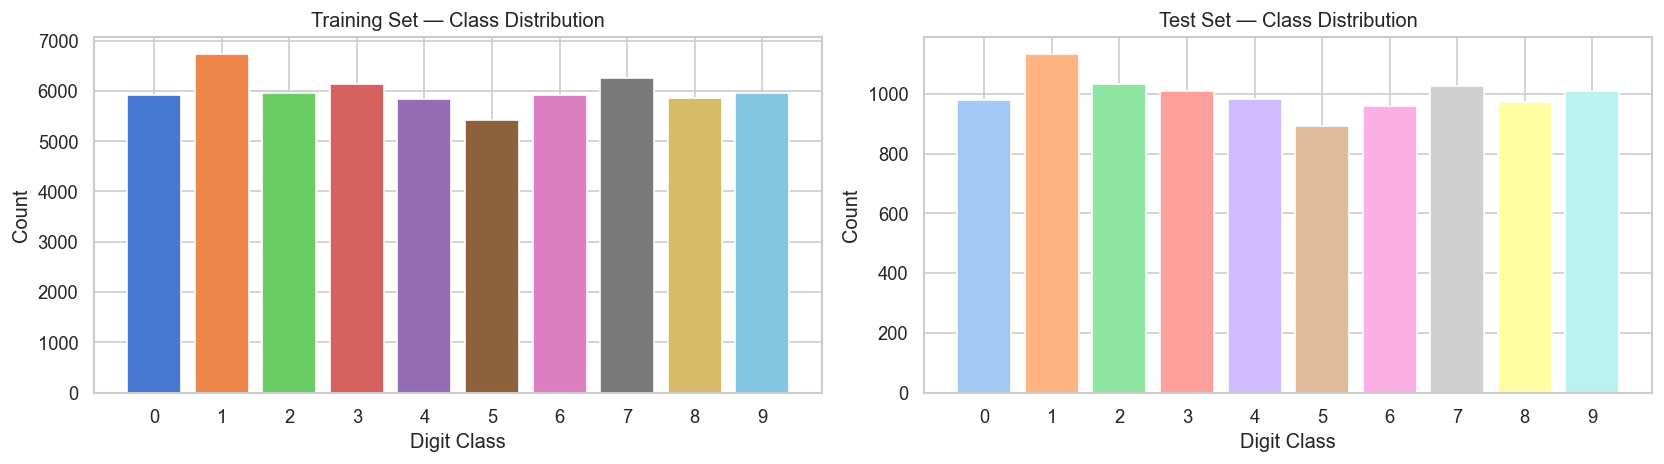


✅ MNIST is well-balanced — no class imbalance correction needed.


In [5]:
# ── Class Distribution ──────────────────────────────────────────────────
train_unique, train_counts = np.unique(y_train, return_counts=True)
test_unique,  test_counts  = np.unique(y_test,  return_counts=True)

dist_df = pd.DataFrame({
    'Digit'         : train_unique,
    'Train Count'   : train_counts,
    'Train %'       : (train_counts / len(y_train) * 100).round(2),
    'Test Count'    : test_counts,
    'Test %'        : (test_counts  / len(y_test)  * 100).round(2)
})

print('CLASS DISTRIBUTION SUMMARY')
print('=' * 50)
print(dist_df.to_string(index=False))
print('=' * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(train_unique, train_counts, color=sns.color_palette('muted', 10))
axes[0].set_title('Training Set — Class Distribution')
axes[0].set_xlabel('Digit Class'); axes[0].set_ylabel('Count')
axes[0].set_xticks(range(10))

axes[1].bar(test_unique, test_counts, color=sns.color_palette('pastel', 10))
axes[1].set_title('Test Set — Class Distribution')
axes[1].set_xlabel('Digit Class'); axes[1].set_ylabel('Count')
axes[1].set_xticks(range(10))

plt.tight_layout()
plt.show()
print('\n✅ MNIST is well-balanced — no class imbalance correction needed.')

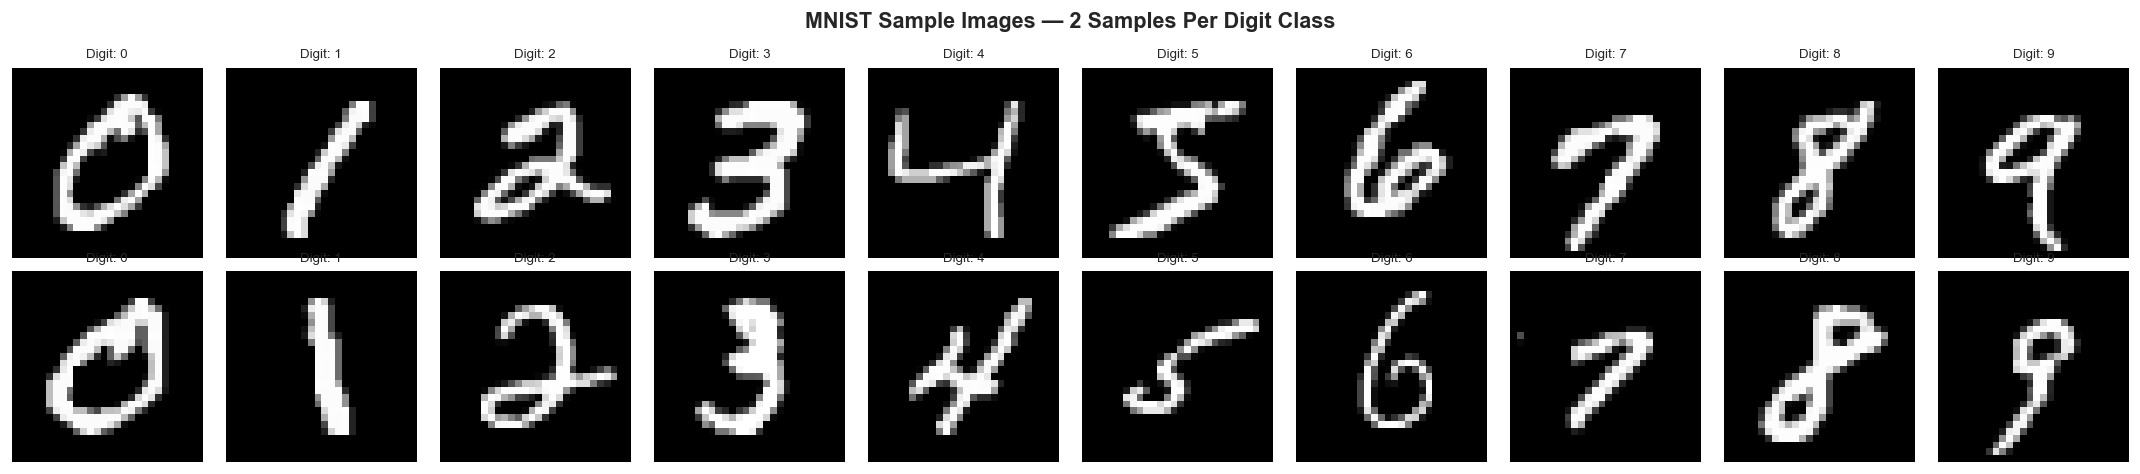

In [6]:
# ── Sample Image Grid (one per class) ────────────────────────────────────
fig, axes = plt.subplots(2, 10, figsize=(18, 4))
fig.suptitle('MNIST Sample Images — 2 Samples Per Digit Class', fontsize=13, fontweight='bold')

for digit in range(10):
    idxs = np.where(y_train == digit)[0][:2]
    for row, idx in enumerate(idxs):
        axes[row, digit].imshow(x_train[idx], cmap='gray')
        axes[row, digit].set_title(f'Digit: {digit}', fontsize=8)
        axes[row, digit].axis('off')

plt.tight_layout()
plt.show()

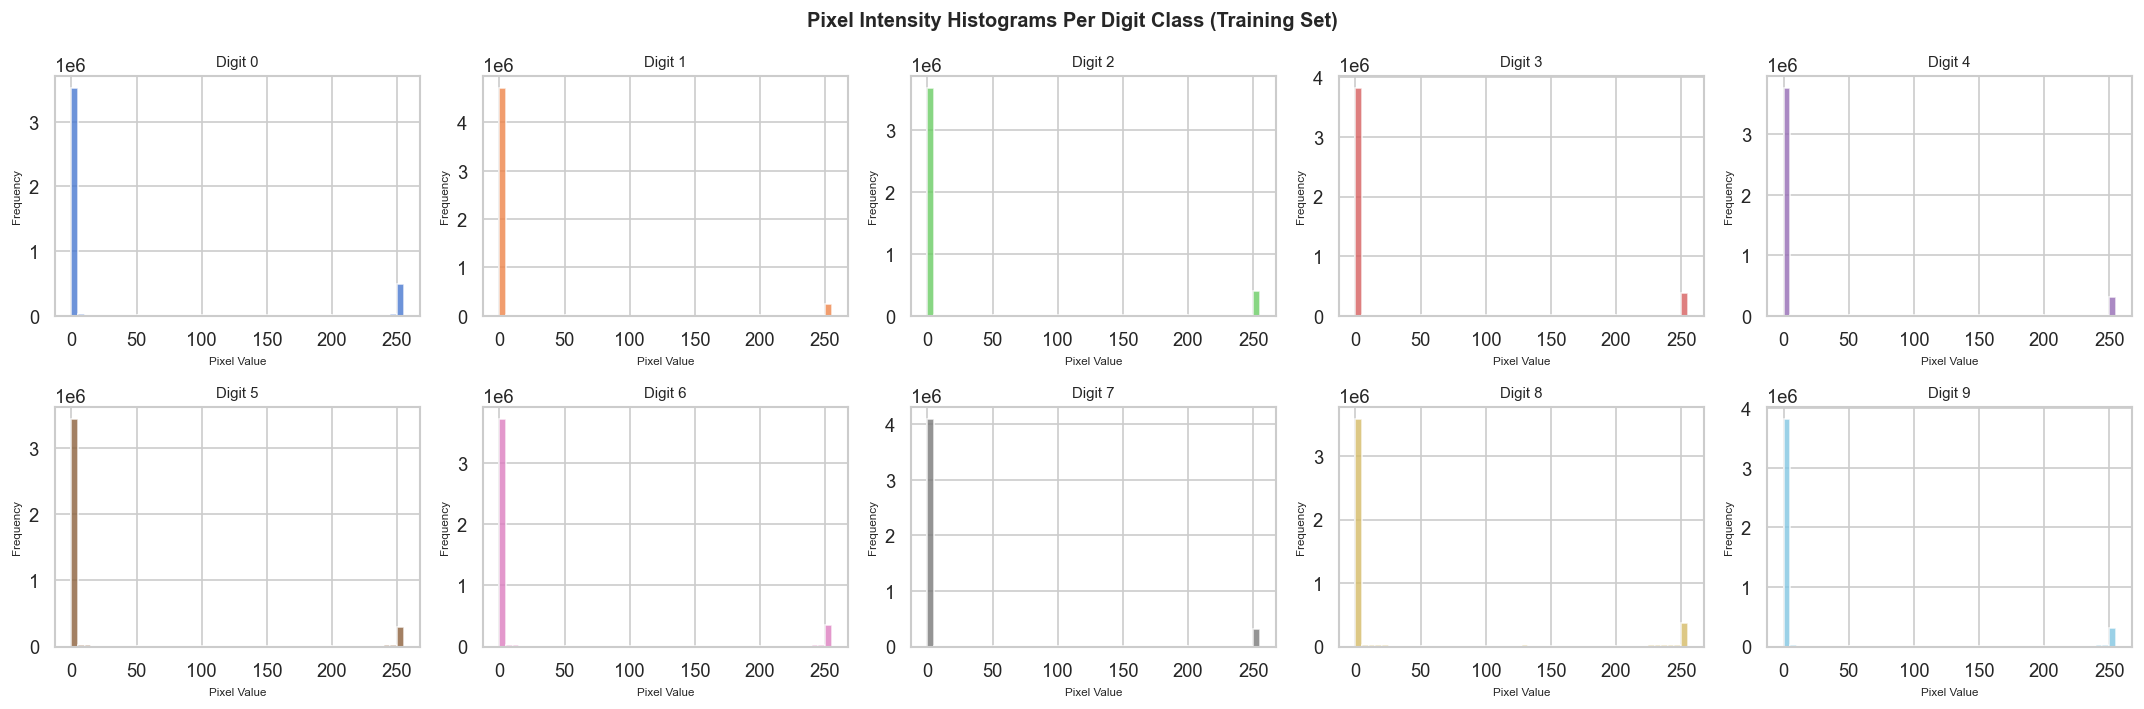


📊 Most pixels are 0 (background). Digits occupy sparse bright regions.


In [7]:
# ── Pixel Intensity Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 6))
fig.suptitle('Pixel Intensity Histograms Per Digit Class (Training Set)', fontsize=12, fontweight='bold')

for digit in range(10):
    ax  = axes[digit // 5][digit % 5]
    pixels = x_train[y_train == digit].flatten()
    ax.hist(pixels, bins=50, color=sns.color_palette('muted', 10)[digit], alpha=0.8)
    ax.set_title(f'Digit {digit}', fontsize=9)
    ax.set_xlabel('Pixel Value', fontsize=7)
    ax.set_ylabel('Frequency', fontsize=7)

plt.tight_layout()
plt.show()
print('\n📊 Most pixels are 0 (background). Digits occupy sparse bright regions.')

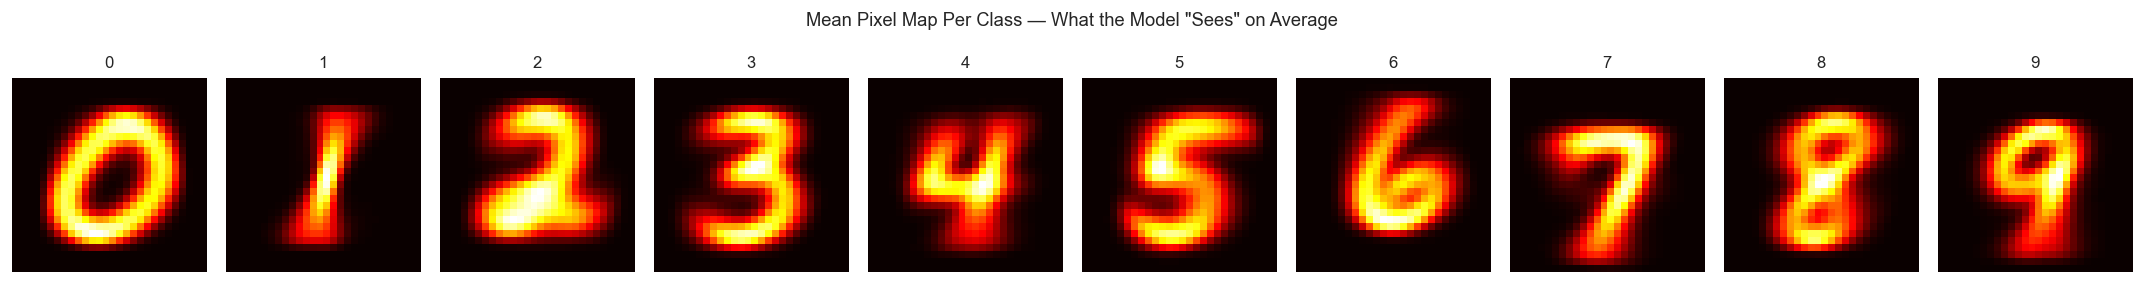

In [8]:
# ── Mean Image Per Class (Average Digit Shape) ───────────────────────────
fig, axes = plt.subplots(1, 10, figsize=(18, 2.5))
fig.suptitle('Mean Pixel Map Per Class — What the Model "Sees" on Average', fontsize=11)

for digit in range(10):
    mean_img = x_train[y_train == digit].mean(axis=0)
    axes[digit].imshow(mean_img, cmap='hot')
    axes[digit].set_title(f'{digit}', fontsize=10)
    axes[digit].axis('off')

plt.tight_layout()
plt.show()

---
## 4. ⚙️ Data Preprocessing

Three preprocessing steps are required before feeding data into the MLP:

1. **Normalization** — Scale pixel values from [0, 255] → [0.0, 1.0]  
   *Why:* Neural networks converge faster and more stably with small input values. Large inputs cause large weight updates and unstable gradients.

2. **Flattening** — The model's `Flatten` layer handles 28×28 → 784 internally.

3. **One-Hot Encoding** — Convert integer labels to categorical vectors  
   *Why:* The output layer uses `softmax` which produces a probability distribution over 10 classes. Cross-entropy loss requires one-hot targets.

In [9]:
# ── Normalize Pixel Values ───────────────────────────────────────────────
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32')  / 255.0

print('NORMALIZATION RESULTS')
print(f'  Before → Min: {x_train.min()}, Max: {x_train.max()}, Mean: {x_train.mean():.2f}')
print(f'  After  → Min: {x_train_norm.min():.4f}, Max: {x_train_norm.max():.4f}, Mean: {x_train_norm.mean():.4f}')

# ── Sanity Check: No NaNs or Infs ───────────────────────────────────────
assert not np.isnan(x_train_norm).any(), 'ERROR: NaN values in training data!'
assert not np.isinf(x_train_norm).any(), 'ERROR: Inf values in training data!'
assert not np.isnan(x_test_norm).any(),  'ERROR: NaN values in test data!'
print('\n✅ Data integrity verified — no NaN or Inf values detected.')

NORMALIZATION RESULTS
  Before → Min: 0, Max: 255, Mean: 33.32
  After  → Min: 0.0000, Max: 1.0000, Mean: 0.1307

✅ Data integrity verified — no NaN or Inf values detected.


In [10]:
# ── One-Hot Encoding ─────────────────────────────────────────────────────
NUM_CLASSES = 10
y_train_enc = keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_enc  = keras.utils.to_categorical(y_test,  NUM_CLASSES)

print('ONE-HOT ENCODING RESULTS')
print(f'  Original label  : {y_train[0]}')
print(f'  Encoded vector  : {y_train_enc[0]}')
print(f'  y_train_enc shape: {y_train_enc.shape}')
print(f'  y_test_enc shape : {y_test_enc.shape}')

# ── Train / Validation / Test Split Explanation ──────────────────────────
print('\nDATA SPLIT SUMMARY')
print(f'  Training data   : {int(len(x_train_norm) * 0.9):,} samples  (90% of 60,000)')
print(f'  Validation data : {int(len(x_train_norm) * 0.1):,} samples  (10% of 60,000, held out during fit)')
print(f'  Test data       : {len(x_test_norm):,} samples  (completely unseen until final eval)')

ONE-HOT ENCODING RESULTS
  Original label  : 5
  Encoded vector  : [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
  y_train_enc shape: (60000, 10)
  y_test_enc shape : (10000, 10)

DATA SPLIT SUMMARY
  Training data   : 54,000 samples  (90% of 60,000)
  Validation data : 6,000 samples  (10% of 60,000, held out during fit)
  Test data       : 10,000 samples  (completely unseen until final eval)


---
## 5. 🏗️ Model Architecture — Multilayer Perceptron

### Design Decisions

| Component | Choice | Justification |
|-----------|--------|---------------|
| Flatten | 28×28 → 784 | MLP requires 1D input |
| Hidden layers | 512 → 256 → 128 | Pyramid shape — progressively abstract features |
| Activation | ReLU | Avoids vanishing gradients vs sigmoid/tanh |
| BatchNormalization | After Dense, before ReLU | Stabilizes distributions, speeds convergence |
| Dropout | 0.4 / 0.3 / 0.2 | Prevents co-adaptation of neurons (regularization) |
| Output activation | Softmax | Outputs probability distribution across 10 classes |
| Loss function | Categorical Cross-Entropy | Standard for multi-class one-hot targets |
| Optimizer | Adam (lr=0.001) | Adaptive learning rate, faster than plain SGD |

> **Note on BatchNorm ordering:** Placing BatchNorm *before* ReLU (Dense → BN → ReLU) normalizes pre-activations,
> which is the original Ioffe & Szegedy (2015) recommendation and yields more stable training.

In [11]:
# ── Build MLP Model ──────────────────────────────────────────────────────
def build_mlp(input_shape=(28, 28), num_classes=10, seed=42):
    """Construct and return a compiled MLP for MNIST digit classification."""
    tf.random.set_seed(seed)

    model = keras.Sequential([
        # ── Input ──────────────────────────────────────────────────────
        layers.Flatten(input_shape=input_shape, name='Input_Flatten'),

        # ── Hidden Layer 1: 512 units ───────────────────────────────────
        layers.Dense(512, name='Dense_1'),
        layers.BatchNormalization(name='BN_1'),
        layers.Activation('relu', name='ReLU_1'),
        layers.Dropout(0.4, seed=seed, name='Dropout_1'),

        # ── Hidden Layer 2: 256 units ───────────────────────────────────
        layers.Dense(256, name='Dense_2'),
        layers.BatchNormalization(name='BN_2'),
        layers.Activation('relu', name='ReLU_2'),
        layers.Dropout(0.3, seed=seed, name='Dropout_2'),

        # ── Hidden Layer 3: 128 units ───────────────────────────────────
        layers.Dense(128, name='Dense_3'),
        layers.BatchNormalization(name='BN_3'),
        layers.Activation('relu', name='ReLU_3'),
        layers.Dropout(0.2, seed=seed, name='Dropout_3'),

        # ── Output Layer: 10 classes ────────────────────────────────────
        layers.Dense(num_classes, activation='softmax', name='Output_Softmax')
    ], name='MLP_Digit_Classifier')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=[
            'accuracy',
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall')
        ]
    )
    return model

model = build_mlp()
model.summary()

Model: "MLP_Digit_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Flatten (Flatten)         │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_1 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_1 (BatchNormalization)       │ (None, 512)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_1 (Activation)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_2 (BatchNormalization)       │ (None, 256)            │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_2 (Activation)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ BN_3 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ReLU_3 (Activation)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Softmax (Dense)          │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

In [12]:
# ── Total Parameter Count Breakdown ──────────────────────────────────────
total     = model.count_params()
trainable = sum([tf.size(v).numpy() for v in model.trainable_variables])
non_train = total - trainable

print(f'Total Parameters     : {total:,}')
print(f'Trainable Parameters : {trainable:,}')
print(f'Non-Trainable Params : {non_train:,}  (BatchNorm running stats)')

Total Parameters     : 571,018
Trainable Parameters : 569,226
Non-Trainable Params : 1,792  (BatchNorm running stats)


---
## 6. 🎨 Model Visualization — Architecture Diagram

The diagram below renders the full **784-input (28×28 pixel grid)** architecture, showing all layers with connection lines.

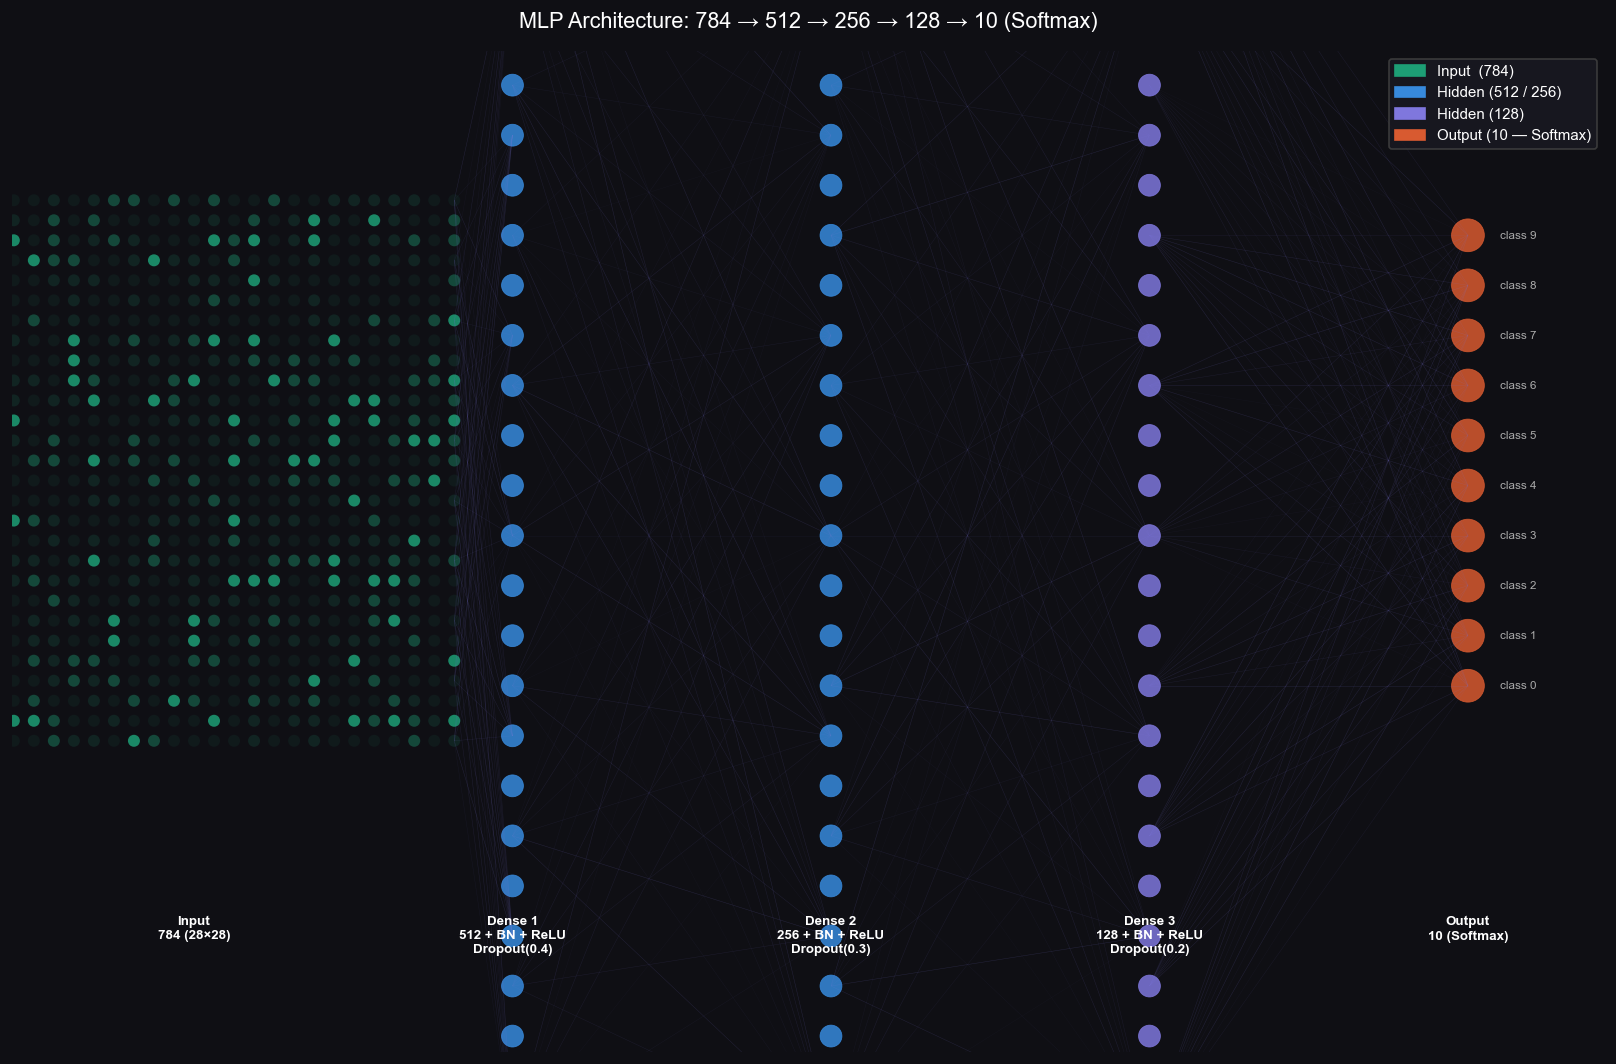

In [13]:
def draw_mlp_architecture():
    fig, ax = plt.subplots(figsize=(18, 9))
    ax.set_facecolor('#0f0f14'); fig.patch.set_facecolor('#0f0f14')

    arch = [
        {'label': 'Input\n784 (28×28)', 'n': 784, 'x': 1.0,  'color': '#1D9E75', 'dot_grid': True},
        {'label': 'Dense 1\n512 + BN + ReLU\nDropout(0.4)', 'n': 512, 'x': 4.5,  'color': '#378ADD'},
        {'label': 'Dense 2\n256 + BN + ReLU\nDropout(0.3)', 'n': 256, 'x': 8.0,  'color': '#378ADD'},
        {'label': 'Dense 3\n128 + BN + ReLU\nDropout(0.2)', 'n': 128, 'x': 11.5, 'color': '#7F77DD'},
        {'label': 'Output\n10 (Softmax)', 'n': 10,  'x': 15.0, 'color': '#D85A30'},
    ]

    MAX_DOTS = 28; DOT_R = 0.12
    GRID_COLS = 28; GRID_ROWS = 28; GRID_STEP = 0.22

    def y_positions(n):
        show = min(n, MAX_DOTS)
        return np.linspace(-(show-1)/2*0.55, (show-1)/2*0.55, show)

    layer_centers = []
    for layer in arch:
        x = layer['x']; color = layer['color']
        if layer.get('dot_grid'):
            gx0 = x - (GRID_COLS * GRID_STEP) / 2
            gy0 = -(GRID_ROWS * GRID_STEP) / 2
            for r in range(GRID_ROWS):
                for c in range(GRID_COLS):
                    alpha = np.random.choice([0.08, 0.15, 0.4, 0.85], p=[0.50, 0.25, 0.15, 0.10])
                    ax.add_patch(plt.Circle((gx0+c*GRID_STEP, gy0+r*GRID_STEP), DOT_R*0.55, color=color, alpha=alpha, linewidth=0))
            grid_right = gx0 + (GRID_COLS-1)*GRID_STEP
            col_ys = np.linspace(gy0, gy0+(GRID_ROWS-1)*GRID_STEP, 10)
            layer_centers.append((grid_right, col_ys))
            label_x = x
        else:
            ys = y_positions(layer['n'])
            is_last = (layer['n'] == 10)
            for y_dot in ys:
                r = DOT_R * (1.5 if is_last else 1.0)
                ax.add_patch(plt.Circle((x, y_dot), r, color=color, alpha=0.85, linewidth=0.5, edgecolor='white'))
                if is_last:
                    idx = int(round((y_dot-ys[0])/(ys[-1]-ys[0]+1e-9)*9))
                    ax.text(x+0.35, y_dot, f'class {idx}', color='#aaaaaa', fontsize=7, va='center')
            layer_centers.append((x, ys))
            label_x = x
        ax.text(label_x, -5.0, layer['label'], ha='center', va='top', color='white', fontsize=8, fontweight='bold')

    for i in range(len(layer_centers)-1):
        x1, ys1 = layer_centers[i]; x2, ys2 = layer_centers[i+1]
        s1 = ys1[::max(1, len(ys1)//8)]; s2 = ys2[::max(1, len(ys2)//6)]
        for y1 in s1:
            for y2 in s2:
                ax.plot([x1, x2], [y1, y2], color='#7F77DD', linewidth=0.3, alpha=np.random.uniform(0.04, 0.20))

    patches = [
        mpatches.Patch(color='#1D9E75', label='Input  (784)'),
        mpatches.Patch(color='#378ADD', label='Hidden (512 / 256)'),
        mpatches.Patch(color='#7F77DD', label='Hidden (128)'),
        mpatches.Patch(color='#D85A30', label='Output (10 — Softmax)'),
    ]
    ax.legend(handles=patches, loc='upper right', facecolor='#1a1a22', edgecolor='#444444', labelcolor='white', fontsize=9)
    ax.set_xlim(-1, 16.5); ax.set_ylim(-6.5, 4.5); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title('MLP Architecture: 784 → 512 → 256 → 128 → 10 (Softmax)', color='white', fontsize=13, pad=14)
    plt.tight_layout(); plt.show()

draw_mlp_architecture()

---
## 7. 🚀 Model Training with Callbacks

### Callbacks Explained

| Callback | Purpose |
|----------|---------|
| `EarlyStopping` | Stops training when `val_loss` stops improving — prevents overfitting and wasted compute |
| `ModelCheckpoint` | Saves the best weights (by `val_accuracy`) automatically during training |
| `ReduceLROnPlateau` | Halves learning rate if `val_loss` stagnates — fine-tunes convergence |
| `CSVLogger` | Logs epoch-by-epoch metrics to a CSV file for external analysis |

In [14]:
import os

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)

# ── Define Callbacks ─────────────────────────────────────────────────────
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='checkpoints/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger('logs/training_log.csv', separator=',', append=False)
]

print('✅ Callbacks configured:')
for cb in callbacks:
    print(f'   • {cb.__class__.__name__}')

✅ Callbacks configured:
   • EarlyStopping
   • ModelCheckpoint
   • ReduceLROnPlateau
   • CSVLogger


In [15]:
# ── Train the Model ──────────────────────────────────────────────────────
BATCH_SIZE = 128
EPOCHS     = 30   # EarlyStopping will halt before this if val_loss stagnates

print('Starting training...\n')
history = model.fit(
    x_train_norm, y_train_enc,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,   # 6,000 samples held as validation
    callbacks=callbacks,
    verbose=1
)
print('\n✅ Training complete!')
print(f'   Epochs run: {len(history.history["accuracy"])}')
print(f'   Best val_accuracy: {max(history.history["val_accuracy"]):.4f}')
print(f'   Best val_loss    : {min(history.history["val_loss"]):.4f}')

Starting training...

Epoch 1/30
417/422 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8078 - loss: 0.6245 - precision: 0.9116 - recall: 0.7186
Epoch 1: val_accuracy improved from None to 0.96733, saving model to checkpoints/best_model.keras

Epoch 1: finished saving model to checkpoints/best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8907 - loss: 0.3665 - precision: 0.9373 - recall: 0.8487 - val_accuracy: 0.9673 - val_loss: 0.1055 - val_precision: 0.9740 - val_recall: 0.9625 - learning_rate: 0.0010
Epoch 2/30
421/422 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9445 - loss: 0.1861 - precision: 0.9562 - recall: 0.9339
Epoch 2: val_accuracy improved from 0.96733 to 0.97400, saving model to checkpoints/best_model.keras

Epoch 2: finished saving model to checkpoints/best_model.keras
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9478 - loss: 0.1733 - precision: 0.9579 - recall: 0.9386 - val_accuracy: 0.9740 - val_loss: 0.0841 - val_precision: 0.9780 - va

---
## 8. 📉 Training Curves

Plotting accuracy and loss over epochs lets us diagnose:
- **Underfitting** — both train and val accuracy are low
- **Overfitting** — train accuracy far exceeds val accuracy
- **Good fit** — both curves converge closely

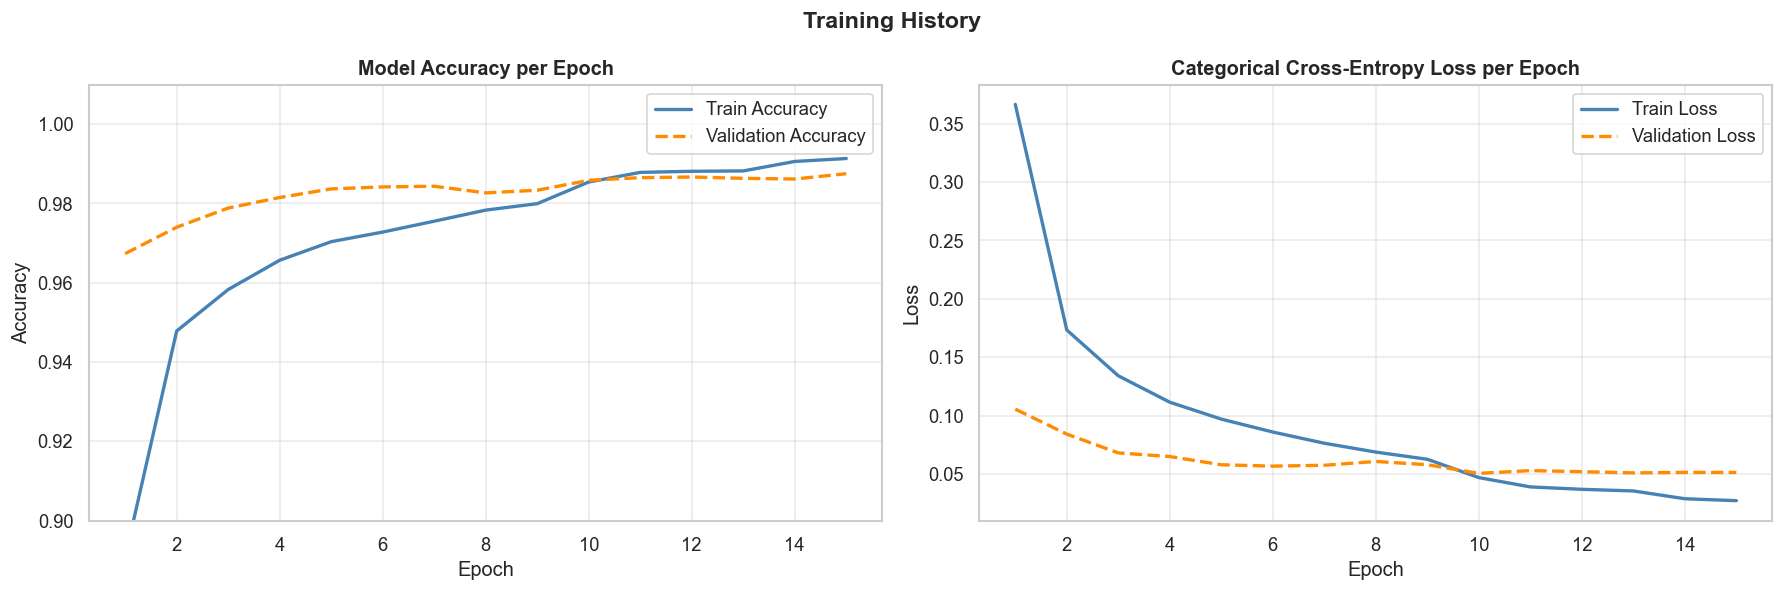

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_ran = range(1, len(history.history['accuracy']) + 1)

# ── Accuracy ─────────────────────────────────────────────────────────────
axes[0].plot(epochs_ran, history.history['accuracy'],     label='Train Accuracy',      color='steelblue',  linewidth=2)
axes[0].plot(epochs_ran, history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy per Epoch', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True, alpha=0.4)
axes[0].set_ylim([0.9, 1.01])

# ── Loss ─────────────────────────────────────────────────────────────────
axes[1].plot(epochs_ran, history.history['loss'],     label='Train Loss',      color='steelblue',  linewidth=2)
axes[1].plot(epochs_ran, history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('Categorical Cross-Entropy Loss per Epoch', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True, alpha=0.4)

plt.suptitle('Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. 🔬 Gradient Flow Analysis

A critical diagnostic step for any neural network. We verify:
- **No vanishing gradients** — gradient norms should not be near zero in early layers
- **No exploding gradients** — gradient norms should not be abnormally large

Healthy gradient norms are generally between **1e-4** and **1.0**.  
BatchNorm helps prevent both issues — this analysis confirms it's working.

In [17]:
# ── Gradient Norm Computation ─────────────────────────────────────────────
sample_batch = x_train_norm[:BATCH_SIZE]
sample_labels = y_train_enc[:BATCH_SIZE]

with tf.GradientTape() as tape:
    predictions = model(sample_batch, training=True)
    loss_val = keras.losses.categorical_crossentropy(sample_labels, predictions)
    loss_val = tf.reduce_mean(loss_val)

gradients = tape.gradient(loss_val, model.trainable_variables)

grad_data = []
for var, grad in zip(model.trainable_variables, gradients):
    if grad is not None:
        norm = tf.norm(grad).numpy()
        mean = tf.reduce_mean(tf.abs(grad)).numpy()
        grad_data.append({'Layer / Variable': var.name, 'Gradient Norm': round(norm, 6), 'Mean |Grad|': round(mean, 8)})

grad_df = pd.DataFrame(grad_data)
print('GRADIENT FLOW ANALYSIS')
print('=' * 65)
print(grad_df.to_string(index=False))
print('=' * 65)

# ── Flags ─────────────────────────────────────────────────────────────────
vanishing = grad_df[grad_df['Gradient Norm'] < 1e-5]
exploding = grad_df[grad_df['Gradient Norm'] > 10.0]
if len(vanishing) == 0 and len(exploding) == 0:
    print('\n✅ Gradients are healthy — no vanishing or exploding detected.')
if len(vanishing) > 0:
    print(f'\n⚠️  Vanishing gradient warning in: {vanishing["Layer / Variable"].tolist()}')
if len(exploding) > 0:
    print(f'\n🔴 Exploding gradient warning in: {exploding["Layer / Variable"].tolist()}')

GRADIENT FLOW ANALYSIS
Layer / Variable  Gradient Norm  Mean |Grad|
          kernel       0.164780     0.000098
            bias       0.000000     0.000000
           gamma       0.019483     0.000581
            beta       0.019202     0.000622
          kernel       0.118277     0.000164
            bias       0.000000     0.000000
           gamma       0.012127     0.000586
            beta       0.016026     0.000782
          kernel       0.071682     0.000268
            bias       0.000000     0.000000
           gamma       0.007833     0.000543
            beta       0.019242     0.001341
          kernel       0.070384     0.000998
            bias       0.011111     0.002498

⚠️  Vanishing gradient warning in: ['bias', 'bias', 'bias']


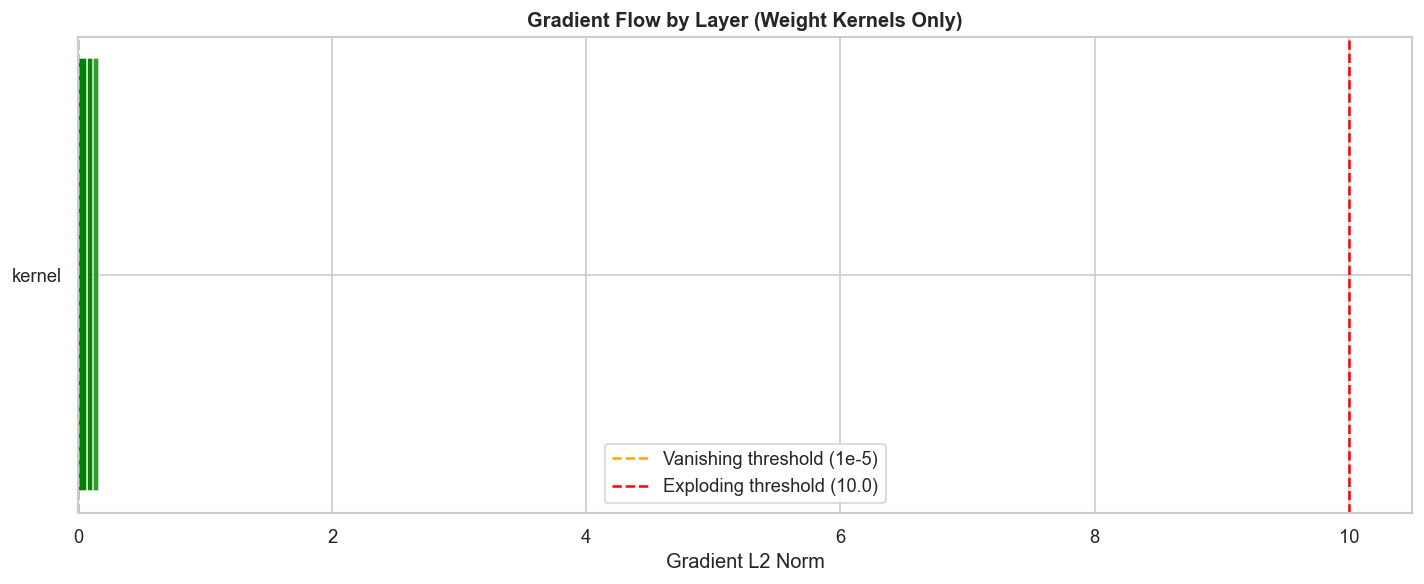

In [18]:
# ── Gradient Norm Bar Chart ───────────────────────────────────────────────
weight_grads = grad_df[grad_df['Layer / Variable'].str.contains('kernel')]

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['green' if 1e-5 < n < 10 else 'red' for n in weight_grads['Gradient Norm']]
ax.barh(weight_grads['Layer / Variable'], weight_grads['Gradient Norm'], color=colors, alpha=0.8)
ax.axvline(x=1e-5, color='orange', linestyle='--', label='Vanishing threshold (1e-5)')
ax.axvline(x=10.0, color='red',    linestyle='--', label='Exploding threshold (10.0)')
ax.set_xlabel('Gradient L2 Norm')
ax.set_title('Gradient Flow by Layer (Weight Kernels Only)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 10. 📊 Model Evaluation & Statistical Metrics

We evaluate on the **completely unseen test set** (10,000 samples never used during training or validation).

| Metric | Formula | Meaning |
|--------|---------|--------|
| Accuracy | TP+TN / Total | Overall correctness |
| Precision | TP / (TP+FP) | Of predicted positives, how many are correct |
| Recall | TP / (TP+FN) | Of actual positives, how many were found |
| F1-Score | 2×P×R / (P+R) | Harmonic mean — balances Precision and Recall |
| ROC-AUC | Area under ROC | Discrimination ability across thresholds |

In [19]:
# ── Generate Predictions ─────────────────────────────────────────────────
y_prob        = model.predict(x_test_norm, verbose=0)
y_pred        = np.argmax(y_prob, axis=1)
y_true        = y_test
y_true_onehot = y_test_enc

# ── Scalar Metrics ────────────────────────────────────────────────────────
acc       = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred,    average='macro')
f1        = f1_score(y_true, y_pred,        average='macro')
roc_auc   = roc_auc_score(y_true_onehot, y_prob, multi_class='ovr', average='macro')

print('=' * 50)
print(f'  TEST ACCURACY   : {acc       * 100:.4f}%')
print(f'  TEST PRECISION  : {precision * 100:.4f}%')
print(f'  TEST RECALL     : {recall    * 100:.4f}%')
print(f'  TEST F1 SCORE   : {f1        * 100:.4f}%')
print(f'  TEST ROC-AUC    : {roc_auc           :.6f}')
print('=' * 50)

print('\nCLASSIFICATION REPORT (Per Digit Class):')
print(classification_report(y_true, y_pred, target_names=[f'Digit {i}' for i in range(10)]))

  TEST ACCURACY   : 98.3700%
  TEST PRECISION  : 98.3667%
  TEST RECALL     : 98.3601%
  TEST F1 SCORE   : 98.3628%
  TEST ROC-AUC    : 0.999838

CLASSIFICATION REPORT (Per Digit Class):
              precision    recall  f1-score   support

     Digit 0       0.98      0.99      0.99       980
     Digit 1       0.99      0.99      0.99      1135
     Digit 2       0.98      0.98      0.98      1032
     Digit 3       0.98      0.98      0.98      1010
     Digit 4       0.98      0.99      0.98       982
     Digit 5       0.99      0.98      0.98       892
     Digit 6       0.99      0.99      0.99       958
     Digit 7       0.98      0.98      0.98      1028
     Digit 8       0.98      0.98      0.98       974
     Digit 9       0.98      0.98      0.98      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



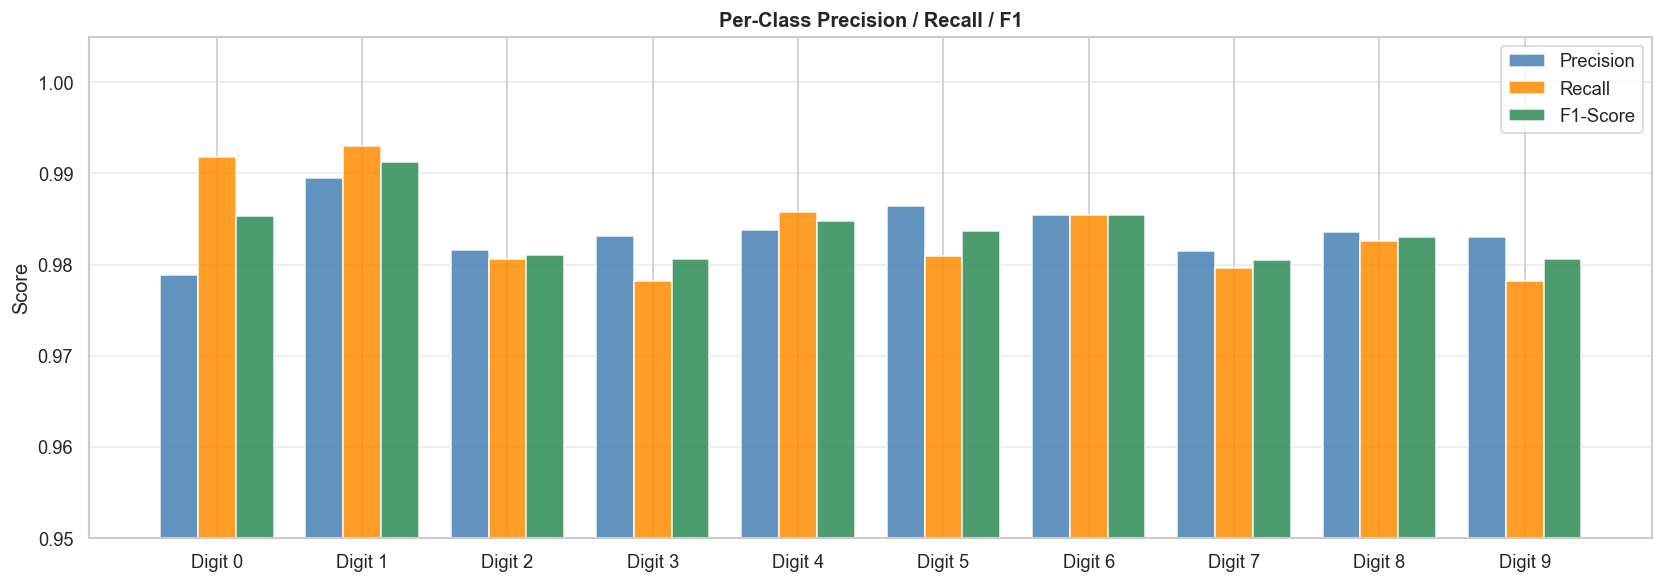

In [20]:
# ── Per-Class Metrics Bar Chart ───────────────────────────────────────────
report = classification_report(y_true, y_pred, output_dict=True)
classes = [str(i) for i in range(10)]
p_scores = [report[c]['precision'] for c in classes]
r_scores = [report[c]['recall']    for c in classes]
f_scores = [report[c]['f1-score']  for c in classes]

x_pos = np.arange(10); w = 0.26
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x_pos - w, p_scores, w, label='Precision', color='steelblue',  alpha=0.85)
ax.bar(x_pos,     r_scores, w, label='Recall',    color='darkorange', alpha=0.85)
ax.bar(x_pos + w, f_scores, w, label='F1-Score',  color='seagreen',   alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels([f'Digit {i}' for i in range(10)])
ax.set_ylim([0.95, 1.005])
ax.set_ylabel('Score'); ax.set_title('Per-Class Precision / Recall / F1', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

---
## 11. 🗺️ Confusion Matrix

The confusion matrix shows which digits are being confused with which others.  
**Diagonal = correct predictions.** Off-diagonal = misclassifications.  
We plot both raw counts and percentage (normalized) versions.

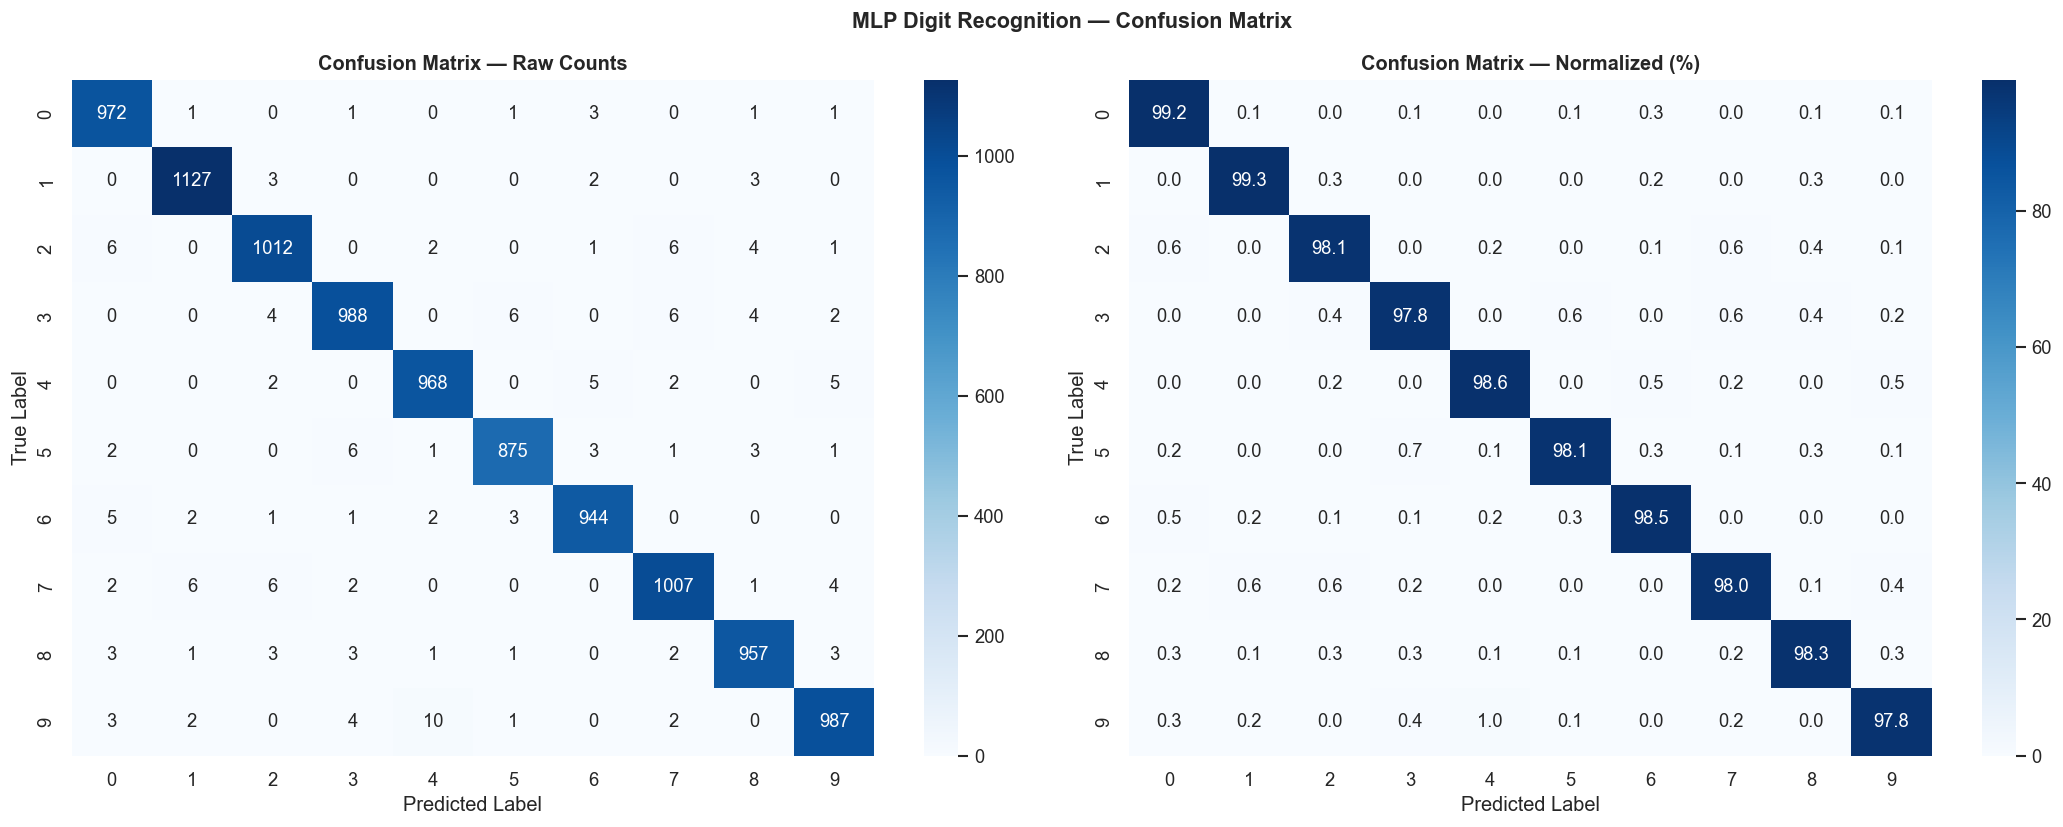


Top 5 Most Confused Digit Pairs (True → Predicted):
   Digit 9 → predicted as 4 : 10 times
   Digit 7 → predicted as 2 : 6 times
   Digit 7 → predicted as 1 : 6 times
   Digit 5 → predicted as 3 : 6 times
   Digit 2 → predicted as 7 : 6 times


In [21]:
cm         = confusion_matrix(y_true, y_pred)
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
labels = [str(i) for i in range(10)]

sns.heatmap(cm,         annot=True, fmt='d',   cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels)
axes[0].set_title('Confusion Matrix — Raw Counts',       fontweight='bold')
axes[0].set_xlabel('Predicted Label'); axes[0].set_ylabel('True Label')

sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', ax=axes[1],
            xticklabels=labels, yticklabels=labels)
axes[1].set_title('Confusion Matrix — Normalized (%)', fontweight='bold')
axes[1].set_xlabel('Predicted Label'); axes[1].set_ylabel('True Label')

plt.suptitle('MLP Digit Recognition — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

# Worst confused pairs
cm_no_diag = cm.copy(); np.fill_diagonal(cm_no_diag, 0)
top_errors = np.dstack(np.unravel_index(np.argsort(cm_no_diag.ravel())[::-1][:5], cm.shape))[0]
print('\nTop 5 Most Confused Digit Pairs (True → Predicted):')
for true, pred in top_errors:
    print(f'   Digit {true} → predicted as {pred} : {cm[true, pred]} times')

---
## 12. 🔎 Misclassification Analysis

Visually inspecting misclassified samples helps us understand *why* the model fails.  
Common causes: ambiguous handwriting, overlapping strokes, unusual styles.

Total misclassifications : 163 out of 10,000
Misclassification rate   : 1.63%
Avg confidence on errors : 76.91%


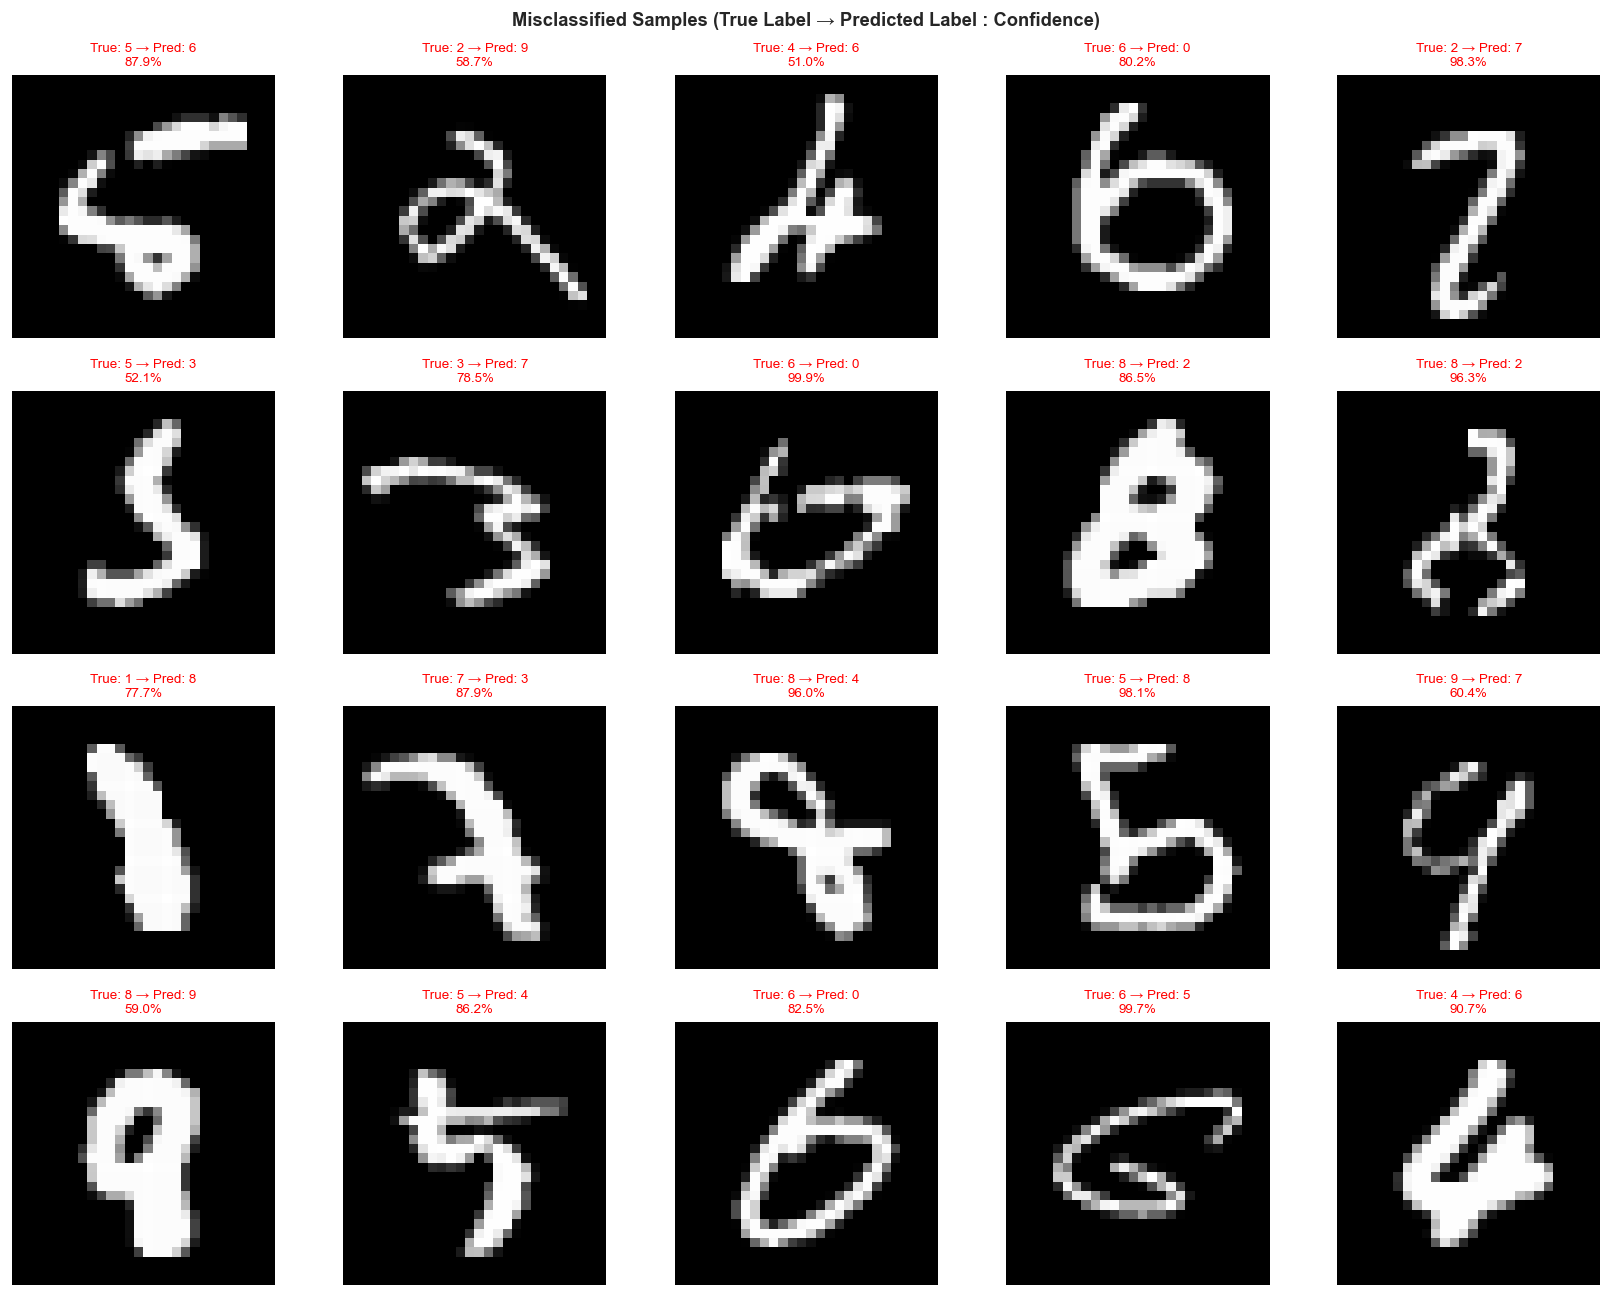

In [22]:
# ── Find All Wrong Predictions ───────────────────────────────────────────
wrong_idx = np.where(y_pred != y_true)[0]
wrong_conf = y_prob[wrong_idx].max(axis=1)

print(f'Total misclassifications : {len(wrong_idx)} out of {len(y_true):,}')
print(f'Misclassification rate   : {len(wrong_idx)/len(y_true)*100:.2f}%')
print(f'Avg confidence on errors : {wrong_conf.mean()*100:.2f}%')

# ── Show 20 Misclassified Samples ────────────────────────────────────────
fig, axes = plt.subplots(4, 5, figsize=(14, 11))
fig.suptitle('Misclassified Samples (True Label → Predicted Label : Confidence)', fontsize=11, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i >= len(wrong_idx): ax.axis('off'); continue
    idx = wrong_idx[i]
    conf = y_prob[idx][y_pred[idx]] * 100
    ax.imshow(x_test[idx], cmap='gray')
    ax.set_title(f'True: {y_true[idx]} → Pred: {y_pred[idx]}\n{conf:.1f}%', fontsize=8, color='red')
    ax.axis('off')

plt.tight_layout(); plt.show()

High-confidence wrong predictions (>90%): 46


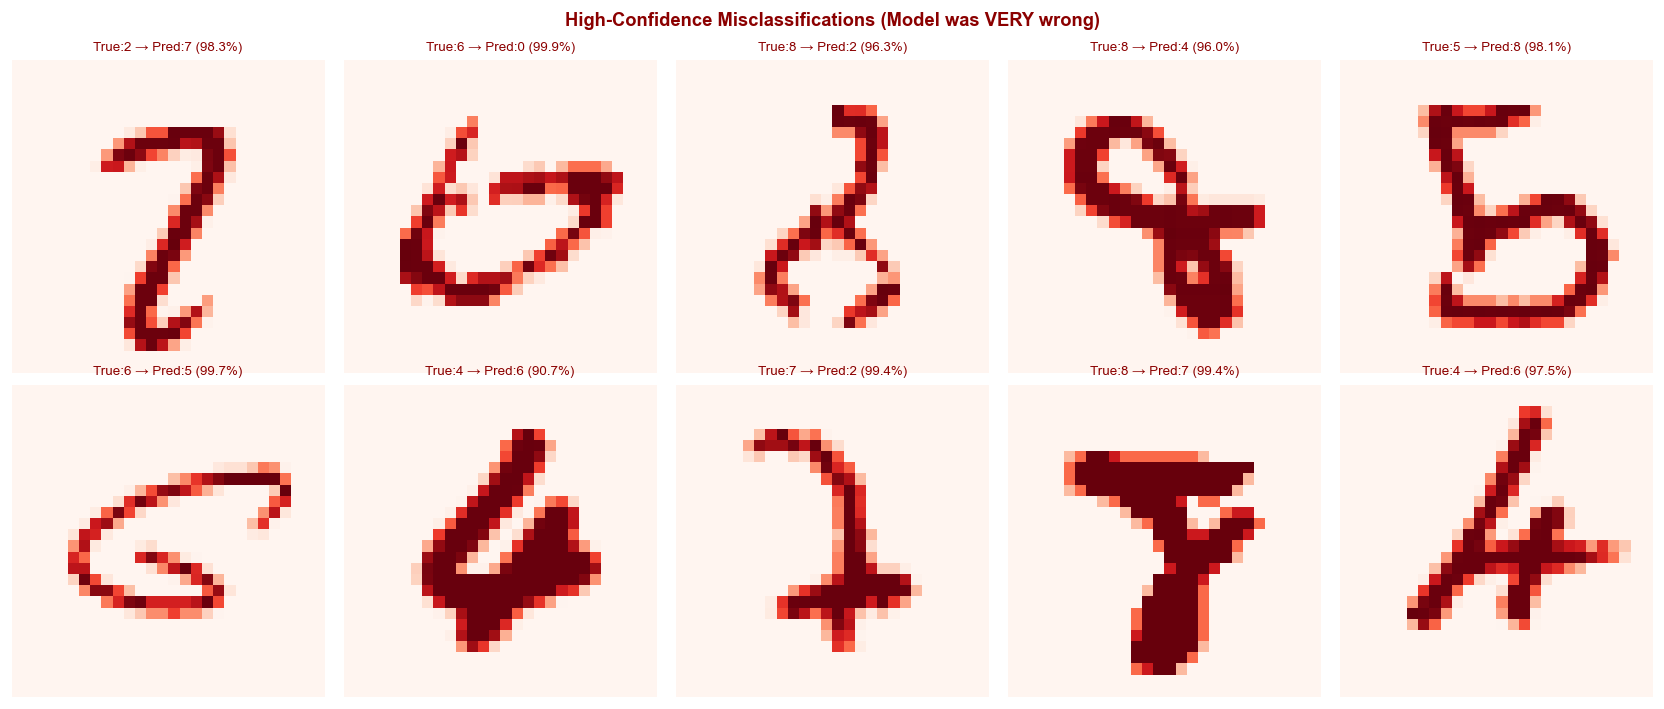

In [23]:
# ── High-Confidence Wrong Predictions (Dangerous Errors) ─────────────────
high_conf_wrong = wrong_idx[wrong_conf > 0.90]
print(f'High-confidence wrong predictions (>90%): {len(high_conf_wrong)}')

if len(high_conf_wrong) > 0:
    n_show = min(10, len(high_conf_wrong))
    fig, axes = plt.subplots(2, 5, figsize=(14, 6))
    fig.suptitle('High-Confidence Misclassifications (Model was VERY wrong)', fontsize=11, color='darkred', fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i >= n_show: ax.axis('off'); continue
        idx = high_conf_wrong[i]
        conf = y_prob[idx][y_pred[idx]] * 100
        ax.imshow(x_test[idx], cmap='Reds')
        ax.set_title(f'True:{y_true[idx]} → Pred:{y_pred[idx]} ({conf:.1f}%)', fontsize=8, color='darkred')
        ax.axis('off')
    plt.tight_layout(); plt.show()
else:
    print('✅ No high-confidence wrong predictions found — model is well-calibrated.')

---
## 13. 📈 Prediction Confidence & ROC-AUC Curves

We analyze how confident the model is on correct vs incorrect predictions,  
and plot the One-vs-Rest ROC curve for each digit class.

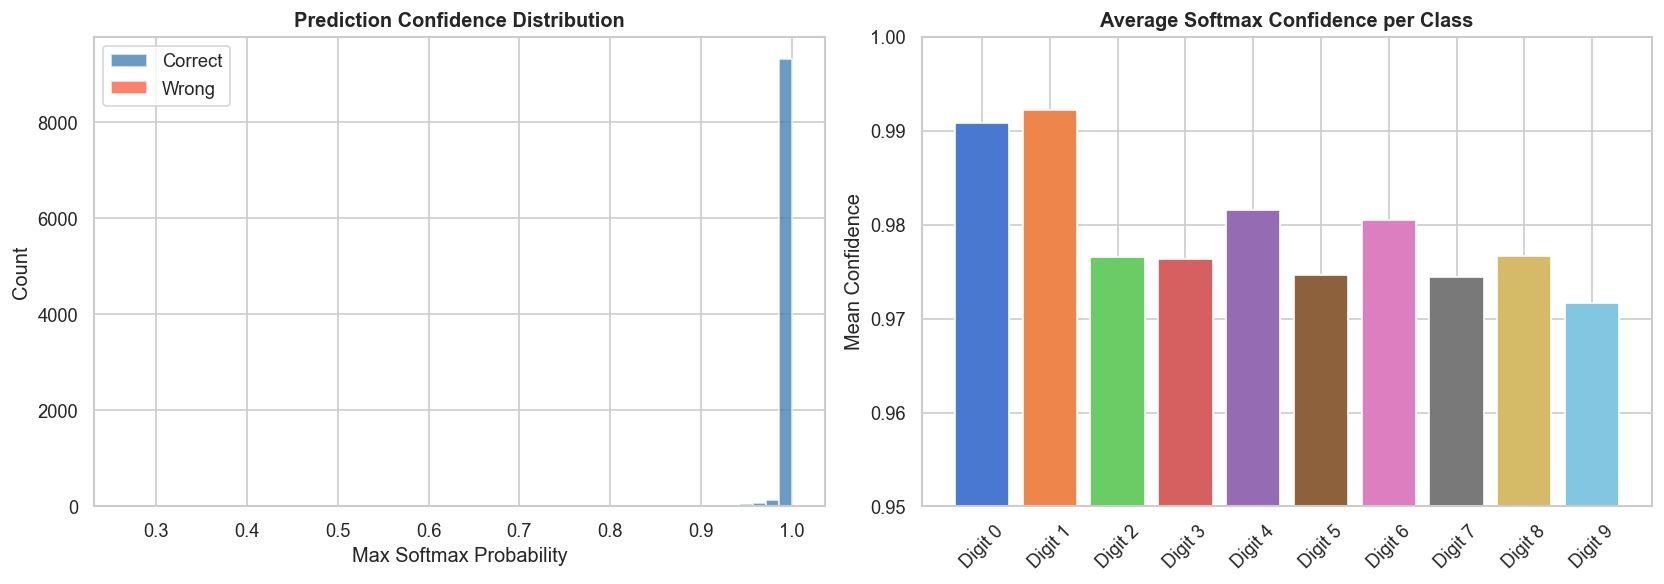

In [24]:
# ── Confidence Distribution: Correct vs Incorrect ────────────────────────
correct_conf = y_prob[y_pred == y_true].max(axis=1)
wrong_conf2  = y_prob[y_pred != y_true].max(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(correct_conf, bins=50, color='steelblue', alpha=0.8, label='Correct')
axes[0].hist(wrong_conf2,  bins=50, color='tomato',    alpha=0.8, label='Wrong')
axes[0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[0].set_xlabel('Max Softmax Probability'); axes[0].set_ylabel('Count')
axes[0].legend()

# ── Per-Class Average Confidence ─────────────────────────────────────────
per_class_conf = [y_prob[y_true == c][:, c].mean() for c in range(10)]
axes[1].bar(range(10), per_class_conf, color=sns.color_palette('muted', 10))
axes[1].set_xticks(range(10)); axes[1].set_xticklabels([f'Digit {i}' for i in range(10)], rotation=45)
axes[1].set_ylim([0.95, 1.0])
axes[1].set_title('Average Softmax Confidence per Class', fontweight='bold')
axes[1].set_ylabel('Mean Confidence')

plt.tight_layout(); plt.show()

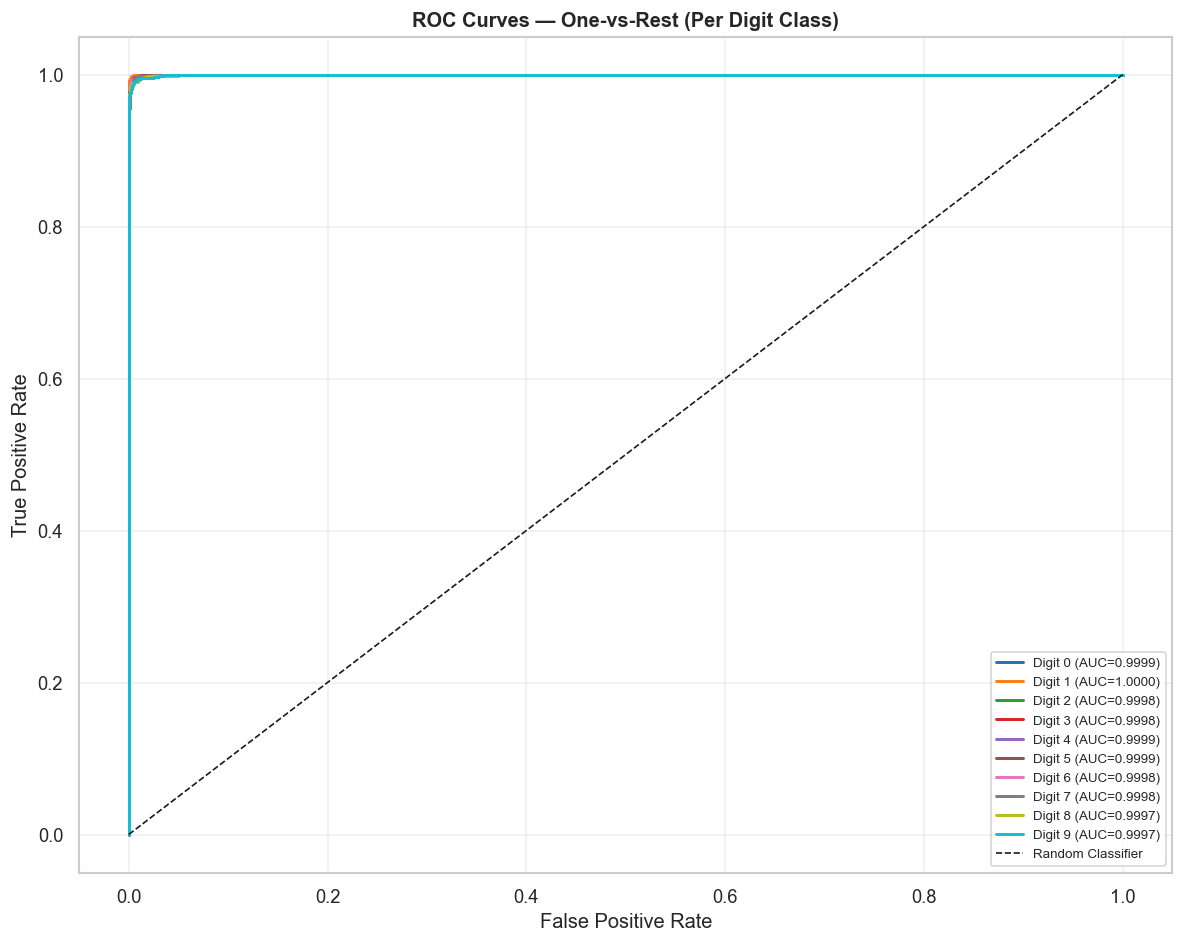

In [25]:
# ── ROC Curves (One-vs-Rest per class) ───────────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(10)))

fig, ax = plt.subplots(figsize=(10, 8))
colors = sns.color_palette('tab10', 10)

for i in range(10):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    auc_score   = roc_auc_score(y_true_bin[:, i], y_prob[:, i])
    ax.plot(fpr, tpr, color=colors[i], linewidth=1.8, label=f'Digit {i} (AUC={auc_score:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves — One-vs-Rest (Per Digit Class)', fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

---
## 14. 🛡️ Robustness / Stress Testing

A production-ready model must handle real-world imperfections.  
We test the model under three degradation conditions:

- **Gaussian Noise** — random pixel perturbations
- **Gaussian Blur** — simulates blurry handwriting / low-res scans
- **Brightness shift** — simulates different lighting conditions

In [26]:
from scipy.ndimage import gaussian_filter

def test_robustness(x, y, noise_std=0.15, blur_sigma=1.5, brightness=0.3):
    results = {}

    # Gaussian noise
    x_noisy = np.clip(x + np.random.normal(0, noise_std, x.shape), 0, 1)
    y_noisy = np.argmax(model.predict(x_noisy, verbose=0), axis=1)
    results['Gaussian Noise'] = accuracy_score(y, y_noisy)

    # Gaussian blur
    x_blur = np.array([gaussian_filter(img, sigma=blur_sigma) for img in x])
    y_blur = np.argmax(model.predict(x_blur, verbose=0), axis=1)
    results['Gaussian Blur'] = accuracy_score(y, y_blur)

    # Brightness shift
    x_bright = np.clip(x + brightness, 0, 1)
    y_bright = np.argmax(model.predict(x_bright, verbose=0), axis=1)
    results['Brightness Shift'] = accuracy_score(y, y_bright)

    # Clean baseline
    y_clean = np.argmax(model.predict(x, verbose=0), axis=1)
    results['Clean (Baseline)'] = accuracy_score(y, y_clean)

    return results

robust_results = test_robustness(x_test_norm[:2000], y_test[:2000])

print('ROBUSTNESS / STRESS TEST RESULTS')
print('=' * 45)
for condition, acc_val in robust_results.items():
    delta = acc_val - robust_results['Clean (Baseline)']
    flag  = '✅' if abs(delta) < 0.05 else ('⚠️' if abs(delta) < 0.15 else '🔴')
    print(f'  {flag} {condition:<22}: {acc_val*100:.2f}%  (Δ {delta*100:+.2f}%)')
print('=' * 45)

ROBUSTNESS / STRESS TEST RESULTS
  ✅ Gaussian Noise        : 94.35%  (Δ -3.55%)
  ⚠️ Gaussian Blur         : 88.85%  (Δ -9.05%)
  🔴 Brightness Shift      : 29.15%  (Δ -68.75%)
  ✅ Clean (Baseline)      : 97.90%  (Δ +0.00%)


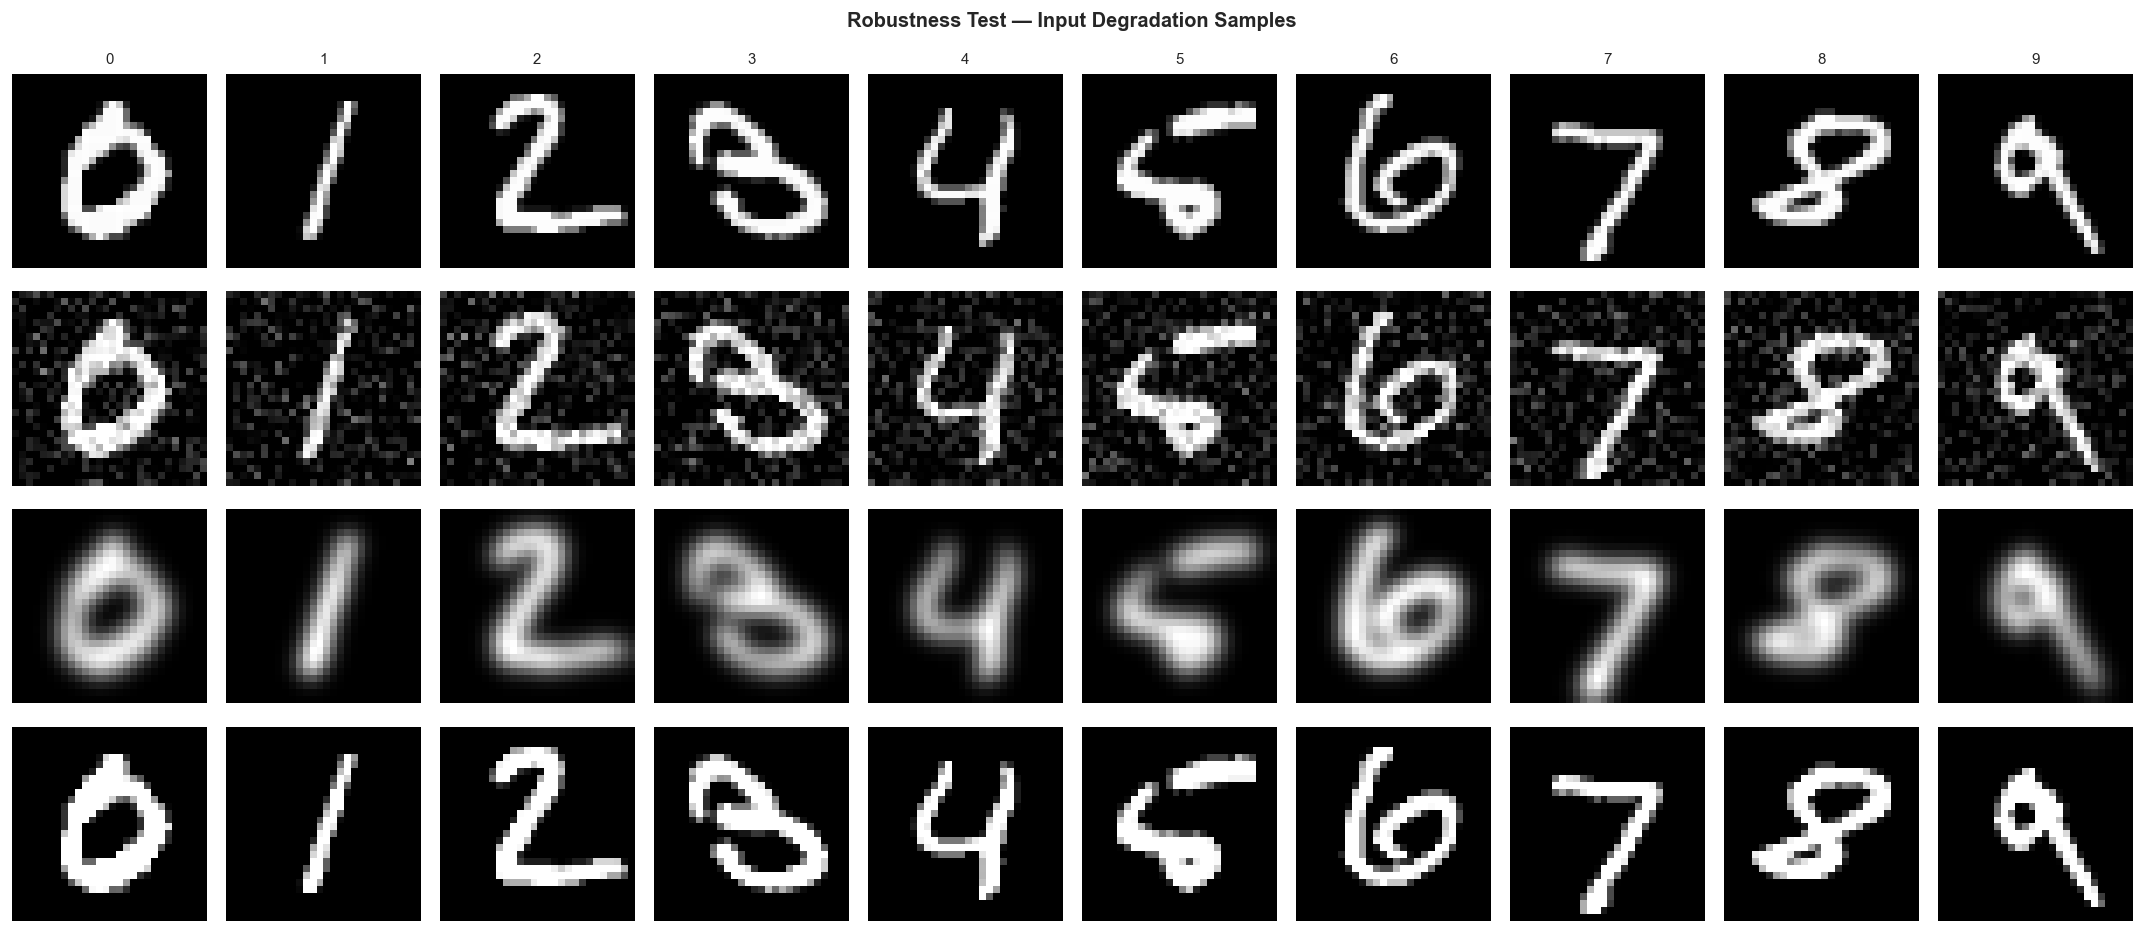

In [27]:
# ── Visual: Clean vs Degraded Samples Side-by-Side ───────────────────────
from scipy.ndimage import gaussian_filter

sample_idxs = [np.where(y_test == d)[0][0] for d in range(10)]
samples = x_test_norm[sample_idxs]

fig, axes = plt.subplots(4, 10, figsize=(18, 8))
row_labels = ['Clean', 'Noisy', 'Blurred', 'Bright']
variants   = [
    samples,
    np.clip(samples + np.random.normal(0, 0.15, samples.shape), 0, 1),
    np.array([gaussian_filter(img, 1.5) for img in samples]),
    np.clip(samples + 0.3, 0, 1)
]

for row, (variant, label) in enumerate(zip(variants, row_labels)):
    for col in range(10):
        axes[row, col].imshow(variant[col], cmap='gray')
        if row == 0: axes[row, col].set_title(f'{col}', fontsize=9)
        if col == 0: axes[row, col].set_ylabel(label, fontsize=8)
        axes[row, col].axis('off')

plt.suptitle('Robustness Test — Input Degradation Samples', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 15. 🔢 Layer-wise Parameter Summary

A full breakdown of the weight and bias tensors per trainable layer —  
shows exactly how many parameters each layer contributes.

In [28]:
layers_info = []

for layer in model.layers:
    if not layer.weights:
        continue
    for w in layer.weights:
        layers_info.append({
            'Layer Name'  : layer.name,
            'Variable'    : w.name.split('/')[-1],
            'Shape'       : str(w.shape.as_list()),
            'Param Count' : int(np.prod(w.shape)),
            'Trainable'   : any(w is v for v in model.trainable_variables)
        })

param_df = pd.DataFrame(layers_info)
print('LAYER PARAMETER BREAKDOWN')
print(param_df.to_string(index=False))
print('\n' + '='*50)
print(f'Total Trainable Params     : {param_df[param_df["Trainable"]]["Param Count"].sum():,}')
print(f'Total Non-Trainable Params : {param_df[~param_df["Trainable"]]["Param Count"].sum():,}')
print(f'Grand Total                : {param_df["Param Count"].sum():,}')

LAYER PARAMETER BREAKDOWN
    Layer Name        Variable      Shape  Param Count  Trainable
       Dense_1          kernel [784, 512]       401408       True
       Dense_1            bias      [512]          512       True
          BN_1           gamma      [512]          512       True
          BN_1            beta      [512]          512       True
          BN_1     moving_mean      [512]          512      False
          BN_1 moving_variance      [512]          512      False
       Dense_2          kernel [512, 256]       131072       True
       Dense_2            bias      [256]          256       True
          BN_2           gamma      [256]          256       True
          BN_2            beta      [256]          256       True
          BN_2     moving_mean      [256]          256      False
          BN_2 moving_variance      [256]          256      False
       Dense_3          kernel [256, 128]        32768       True
       Dense_3            bias      [128]         

---
## 16. 💾 Model Export

We export the trained model in the modern Keras format (`.keras`) for use in the frontend/backend inference pipeline.  
We also verify the saved model loads correctly and produces identical predictions.

In [29]:
import os

MODEL_DIR  = '../backend/model'
MODEL_PATH = os.path.join(MODEL_DIR, 'digit_model.keras')

os.makedirs(MODEL_DIR, exist_ok=True)
model.save(MODEL_PATH)
print(f'✅ Model saved to: {MODEL_PATH}')

# ── Verify Reload ────────────────────────────────────────────────────────
loaded_model = keras.models.load_model(MODEL_PATH)
y_reload     = np.argmax(loaded_model.predict(x_test_norm[:10], verbose=0), axis=1)
y_original   = np.argmax(model.predict(x_test_norm[:10], verbose=0), axis=1)

assert np.array_equal(y_reload, y_original), 'ERROR: Reload mismatch!'
print('✅ Reload verified — saved model is identical to trained model.')
print(f'   Sample predictions: {y_original.tolist()}')

✅ Model saved to: ../backend/model\digit_model.keras
✅ Reload verified — saved model is identical to trained model.
   Sample predictions: [7, 2, 1, 0, 4, 1, 4, 9, 6, 9]


In [30]:
# ── Export Training Log CSV ──────────────────────────────────────────────
log_df = pd.read_csv('logs/training_log.csv')
print('TRAINING LOG (Last 5 Epochs):')
print(log_df.tail().to_string(index=False))

# ── Final Summary ─────────────────────────────────────────────────────────
print('\n' + '='*55)
print('  FINAL MODEL SUMMARY')
print('='*55)
print(f'  Architecture  : 784 → 512 → 256 → 128 → 10')
print(f'  Regularization: BatchNorm + Dropout (0.4 / 0.3 / 0.2)')
print(f'  Optimizer     : Adam (initial lr=0.001)')
print(f'  Test Accuracy : {acc*100:.4f}%')
print(f'  Test F1 Score : {f1*100:.4f}%')
print(f'  ROC-AUC       : {roc_auc:.6f}')
print(f'  Epochs run    : {len(history.history["accuracy"])}')
print(f'  Model path    : {MODEL_PATH}')
print('='*55)

TRAINING LOG (Last 5 Epochs):
 epoch  accuracy  learning_rate     loss  precision   recall  val_accuracy  val_loss  val_precision  val_recall
    10  0.987833        0.00050 0.038835   0.989227 0.986296      0.986500  0.052803       0.987485    0.986333
    11  0.988111        0.00050 0.036784   0.989511 0.987019      0.986667  0.051870       0.987807    0.985667
    12  0.988204        0.00050 0.035381   0.989585 0.987148      0.986333  0.050859       0.987974    0.985833
    13  0.990593        0.00025 0.028705   0.991649 0.989519      0.986167  0.051280       0.987314    0.985833
    14  0.991333        0.00025 0.027040   0.992136 0.990556      0.987500  0.051203       0.988483    0.987000

  FINAL MODEL SUMMARY
  Architecture  : 784 → 512 → 256 → 128 → 10
  Regularization: BatchNorm + Dropout (0.4 / 0.3 / 0.2)
  Optimizer     : Adam (initial lr=0.001)
  Test Accuracy : 98.3700%
  Test F1 Score : 98.3628%
  ROC-AUC       : 0.999838
  Epochs run    : 15
  Model path    : ../backend/m